# Лабораторна робота №2. Попередня обробка даних та формування простору ознак
### Проєкт DocVerify — класифікація типу бізнес-документа та перевірка автентичності

Ця лабораторна робота будується на результаті Лаб.1 (`data/real/<клас>/*.png` +
`data/metadata_real.csv`, 20 реальних класів документів, 3682 зображення). Тут ми:
1. Формуємо повноцінний простір числових ознак із самих зображень (Задача 1).
2. Проводимо другий, структурований раунд препроцесингу (пропуски, викиди, кодування,
   масштабування, відбір ознак).
3. Навчаємо перший базовий класифікатор (k-NN) і порівнюємо «сирі» та «оброблені» дані,
   щоб продемонструвати, чому кожен крок препроцесингу важливий.


In [1]:
# ==================== КОНФІГУРАЦІЙНИЙ БЛОК ====================
import os

DATA_DIR = "data/real"                       # тека із зображеннями (підпапки = класи)
METADATA_CSV = "data/metadata_real.csv"      # вхідна таблиця метаданих (результат Лаб.1)
FEATURES_CSV = "data/features_lab2.csv"      # вихідна таблиця з новими ознаками (ця лабораторна)
TARGET = "document_type"                     # цільова змінна
AUTH_COLUMN = "authenticity"                 # друга (допоміжна) цільова змінна / ознака
RANDOM_STATE = 42
TEST_SIZE = 0.2
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)

## 2. Формування простору ознак (Задача 1)

Для кожного зображення з `metadata_real.csv` обчислюємо 5 нових числових ознак:
- `aspect_ratio` = width / height;
- `mean_brightness` — середня яскравість у відтінках сірого (0-255);
- `std_brightness` — стандартне відхилення яскравості (проксі контрасту);
- `dark_pixel_ratio` — частка «темних» пікселів (< 128) у відтінках сірого (проксі щільності
  тексту/чорнила);
- `color_saturation_mean` — середня насиченість (канал S у HSV), обчислена на ОРИГІНАЛЬНОМУ
  кольоровому зображенні, ДО переведення у відтінки сірого.

Класи зчитуються динамічно з `metadata_real.csv` 

In [2]:
def compute_image_features(filepath):
    """Обчислює 4 ознаки, що вимагають відкриття зображення
    (aspect_ratio рахується окремо, напряму з width/height)."""
    with Image.open(filepath) as im:
        im_rgb = im.convert('RGB')
        saturation = np.asarray(im_rgb.convert('HSV'), dtype=np.float64)[:, :, 1]
        gray = np.asarray(im_rgb.convert('L'), dtype=np.float64)
    return {
        'mean_brightness': gray.mean(),
        'std_brightness': gray.std(),
        'dark_pixel_ratio': (gray < 128).mean(),
        'color_saturation_mean': saturation.mean(),
    }

meta = pd.read_csv(METADATA_CSV)
meta['filepath'] = meta['filename'].apply(lambda x: os.path.join(DATA_DIR, x))

print(f"Класів у metadata_real.csv: {meta[TARGET].nunique()} (зчитано динамічно)")
print(f"Обчислення ознак для {len(meta)} зображень...")

feat_records = []
for i, path in enumerate(meta['filepath']):
    feat_records.append(compute_image_features(path))
    if (i + 1) % 500 == 0 or (i + 1) == len(meta):
        print(f"  оброблено {i + 1}/{len(meta)}")

feat_df = pd.DataFrame(feat_records, index=meta.index)
meta['aspect_ratio'] = meta['width'] / meta['height']
meta['mean_brightness'] = feat_df['mean_brightness']
meta['std_brightness'] = feat_df['std_brightness']
meta['dark_pixel_ratio'] = feat_df['dark_pixel_ratio']
meta['color_saturation_mean'] = feat_df['color_saturation_mean']

meta = meta.drop(columns=['filepath'])
meta.to_csv(FEATURES_CSV, index=False)
print(f"\nЗбережено {FEATURES_CSV}: {meta.shape}")
meta.head()

Класів у metadata_real.csv: 20 (зчитано динамічно)
Обчислення ознак для 3682 зображень...


  оброблено 500/3682


  оброблено 1000/3682


  оброблено 1500/3682


  оброблено 2000/3682


  оброблено 2500/3682


  оброблено 3000/3682


  оброблено 3500/3682


  оброблено 3682/3682

Збережено data/features_lab2.csv: (3682, 12)


,filename,document_type,source_dataset,authenticity,width,height,file_size_bytes,aspect_ratio,mean_brightness,std_brightness,dark_pixel_ratio,color_saturation_mean
0,rahunok/rahunok_0000.png,рахунок,RVL-CDIP,NaN,802,1000,100163,0.802,250.871021,26.578634,0.015262,0.0
1,rahunok/rahunok_0001.png,рахунок,RVL-CDIP,NaN,777,1000,198897,0.777,234.195624,65.284716,0.080224,0.0
2,rahunok/rahunok_0002.png,рахунок,RVL-CDIP,NaN,754,1000,349049,0.754,231.765775,62.040539,0.083447,0.0
3,rahunok/rahunok_0003.png,рахунок,RVL-CDIP,NaN,776,1000,136111,0.776,246.799001,39.766490,0.031683,0.0
4,rahunok/rahunok_0004.png,рахунок,RVL-CDIP,NaN,775,1000,188636,0.775,244.556391,42.629211,0.039920,0.0


In [3]:
print("Середня насиченість (color_saturation_mean) за джерелом даних:")
print(meta.groupby('source_dataset')['color_saturation_mean'].mean().round(2).sort_values())

Середня насиченість (color_saturation_mean) за джерелом даних:
source_dataset
RVL-CDIP                                                0.00
SROIE/CORD                                             43.60
Synthetic Passports Dataset (Kaggle)                   47.96
Dummy KTP Indonesia (Kaggle)                           52.62
MIDV-500 (Wikimedia Commons, FTP smartengines.com)    103.28
Name: color_saturation_mean, dtype: float64


**Примітка щодо `color_saturation_mean`:** як і очікувалось, скановані документи RVL-CDIP
(рахунок, лист, форма, email тощо) дають значення, близькі до нуля (сірошкальні скани технічно
можуть мати невелику залишкову насиченість через шум/компресію JPEG, але вона мінімальна), тоді
як фотографічні класи (квитанція, паспорт, ID-картка, посвідчення водія) мають помітно вищу
насиченість — це підтверджує, що ознака коректно вловлює різницю «скан проти фото», яку ми вже
відзначали в Лаб.1 за розміром файлу.

## 3. EDA на новій таблиці ознак

In [4]:
df = pd.read_csv(FEATURES_CSV)
print("Розмір:", df.shape)
print("\nТипи даних:\n", df.dtypes)
print("\nПропуски по стовпцях:\n", df.isnull().sum())
print("\nПовні дублікати рядків:", df.duplicated().sum())
display(df.describe())

Розмір: (3682, 12)

Типи даних:
 filename                  object
document_type             object
source_dataset            object
authenticity              object
width                      int64
height                     int64
file_size_bytes            int64
aspect_ratio             float64
mean_brightness          float64
std_brightness           float64
dark_pixel_ratio         float64
color_saturation_mean    float64
dtype: object

Пропуски по стовпцях:
 filename                    0
document_type               0
source_dataset              0
authenticity             3349
width                       0
height                      0
file_size_bytes             0
aspect_ratio                0
mean_brightness             0
std_brightness              0
dark_pixel_ratio            0
color_saturation_mean       0
dtype: int64

Повні дублікати рядків: 0


,width,height,file_size_bytes,aspect_ratio,mean_brightness,std_brightness,dark_pixel_ratio,color_saturation_mean
count,3682.000000,3682.000000,3.682000e+03,3682.000000,3682.000000,3682.000000,3682.000000,3682.000000
mean,774.520913,1012.769962,3.708998e+05,0.786662,219.849940,51.318891,0.127221,10.578804
std,157.522100,305.434914,5.344759e+05,0.170690,44.607383,22.175463,0.179640,28.144801
min,278.000000,265.000000,1.021400e+04,0.337895,22.290615,5.468237,0.000629,0.000000
25%,754.000000,1000.000000,1.359170e+05,0.754000,217.754022,36.603063,0.030544,0.000000
50%,754.000000,1000.000000,2.252265e+05,0.754000,239.771780,48.716941,0.056894,0.000000
75%,777.000000,1000.000000,3.943080e+05,0.777000,246.829167,61.566650,0.121208,0.000000
max,2304.000000,4096.000000,7.113266e+06,1.700680,254.821107,126.919761,0.936663,169.889369


Пропуски зосереджені виключно в `authenticity` (застосовна лише до класів «квитанція» й
«паспорт»). Повних дублікатів рядків (за всіма стовпцями) немає — навіть 5 зображень-дублікатів
за вмістом файлу, знайдених у Лаб.1, мають різні `filename`, тому не є дублікатами рядків тут.

## 4. Пропущені значення: `authenticity`

Пропуски в `authenticity` 
**концептуально невизначені** для класів, де підробка просто не має сенсу (рахунок, лист, форма
тощо — ми ніколи не перевіряли й не могли перевірити їхню «автентичність» у сенсі
«справжній/підроблений документ», бо в джерелах даних такого поняття для них немає).

Порівняємо дві стратегії:

In [5]:
mode_value = df[AUTH_COLUMN].mode(dropna=True)[0]
df_strategy_a = df.copy()
df_strategy_a[AUTH_COLUMN] = df_strategy_a[AUTH_COLUMN].fillna(mode_value)

df_strategy_b = df.copy()
df_strategy_b[AUTH_COLUMN] = df_strategy_b[AUTH_COLUMN].fillna('not_applicable')

print(f"(a) Мода-імпутація (заповнення значенням '{mode_value}'):")
print(df_strategy_a[AUTH_COLUMN].value_counts())
print(f"\n(b) Сентинел-категорія 'not_applicable':")
print(df_strategy_b[AUTH_COLUMN].value_counts())

(a) Мода-імпутація (заповнення значенням 'genuine'):
authenticity
genuine    3682
Name: count, dtype: int64

(b) Сентинел-категорія 'not_applicable':
authenticity
not_applicable    3349
genuine            333
Name: count, dtype: int64


**(a) Мода-імпутація — семантично неправильно.** Заповнення тисяч пропусків значенням
`"genuine"` буквально ВИГАДУЄ твердження «цей документ перевірено і визнано справжнім» для
кожного рахунку, листа, форми тощо — перевірки, якої ніколи не відбувалось. Це не просто
неточно, а вводить в оману: майбутній класифікатор автентичності може навчитися хибної
кореляції «тип документа X → завжди genuine», хоча насправді ми просто ніколи не мали способу
дізнатися.

**(b) Сентинел-категорія `"not_applicable"`. Вона чесно кодує реальний
стан справ: «для цього рядка ознака автентичності не застосовна», а не «автентичність невідома,
але існує». Це третя, окрема категорія (поряд із `genuine`/`forged`), яку One-Hot Encoding
(розділ 6) перетворить на свій власний стовпець — модель отримує явну інформацію «цей клас не
підлягає перевірці автентичності» замість хибного сигналу.

Надалі використовуємо стратегію (b):

In [6]:
df[AUTH_COLUMN] = df[AUTH_COLUMN].fillna('not_applicable')
print(df[AUTH_COLUMN].value_counts())

authenticity
not_applicable    3349
genuine            333
Name: count, dtype: int64


## 5. Викиди: IQR-метод (`width`, `file_size_bytes`)

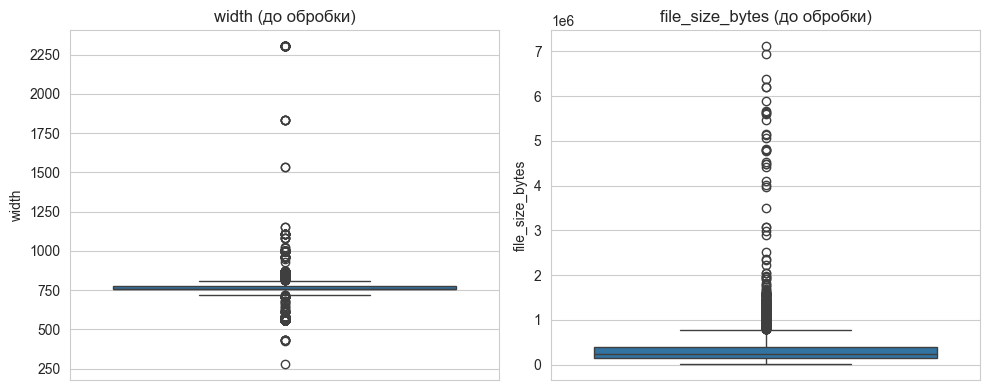

width: IQR-межі = [719.5, 811.5], викидів за межами: 575
file_size_bytes: IQR-межі = [-251669.5, 781894.5], викидів за межами: 367

Після capping:
     width  file_size_bytes
min  719.5          10214.0
max  811.5         781894.5


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['width'], ax=axes[0])
axes[0].set_title('width (до обробки)')
sns.boxplot(y=df['file_size_bytes'], ax=axes[1])
axes[1].set_title('file_size_bytes (до обробки)')
plt.tight_layout()
plt.savefig('fig_lab2_outliers_before.png', dpi=120)
plt.show()

def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ['width', 'file_size_bytes']:
    lo, hi = iqr_bounds(df[col])
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: IQR-межі = [{lo:.1f}, {hi:.1f}], викидів за межами: {n_outliers}")
    df[col] = df[col].clip(lower=lo, upper=hi)

print("\nПісля capping:")
print(df[['width', 'file_size_bytes']].describe().loc[['min', 'max']])

**Чому capping, а не видалення** (та сама логіка, що й у Лаб.1): «викиди» тут — це переважно
легітимні реальні фотографії (квитанція, паспорт, посвідчення водія, ID-картка), розмір і
роздільна здатність яких природно ширші за однорідні скани RVL-CDIP. Видалення цих рядків
означало б систематично вирізати саме ці класи з датасету (адже саме вони дають більшість
«викидів»), спотворюючи баланс класів і викидаючи цілком валідні дані. Capping (обрізання до
меж IQR) зберігає всі рядки, лише приборкує екстремальні значення для стабільнішого
масштабування.

## 6. Кодування категоріальних ознак

`source_dataset` і (тепер уже заповнений) `authenticity` — обидва номінальні (без природного
порядку), тому кодуємо їх One-Hot Encoding. Цільову змінну `document_type` кодуємо окремо через
`LabelEncoder` (для неї порядок кодів не має значення — це лише ідентифікатори класів для
метрик і `stratify`).

**Демонстрація нижче виконана на повному наборі — лише для ілюстрації того, що саме роблять ці
трансформації.** Реальний пайплайн, який іде в модель (розділ 9), перенавчає encoder і scaler
ЛИШЕ на train, щоб уникнути витоку даних — так само, як у Лаб.1.

In [8]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

CATEGORICAL_COLS = ['source_dataset', AUTH_COLUMN]

_demo_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
_demo_encoded = _demo_ohe.fit_transform(df[CATEGORICAL_COLS])
_demo_encoded_df = pd.DataFrame(_demo_encoded, columns=_demo_ohe.get_feature_names_out(CATEGORICAL_COLS))
print("Приклад One-Hot кодування (перші 5 рядків, лише нові стовпці):")
display(_demo_encoded_df.head())

le_target = LabelEncoder()
y_all = le_target.fit_transform(df[TARGET])
print("\nВідповідність код -> клас (document_type):")
for code_, label in enumerate(le_target.classes_):
    print(f"  {code_:2d} -> {label}")

Приклад One-Hot кодування (перші 5 рядків, лише нові стовпці):


,source_dataset_Dummy KTP Indonesia (Kaggle),"source_dataset_MIDV-500 (Wikimedia Commons, FTP smartengines.com)",source_dataset_RVL-CDIP,source_dataset_SROIE/CORD,source_dataset_Synthetic Passports Dataset (Kaggle),authenticity_genuine,authenticity_not_applicable
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Відповідність код -> клас (document_type):
   0 -> ID-картка
   1 -> email
   2 -> анкета
   3 -> бюджет
   4 -> квитанція
   5 -> лист
   6 -> наукова публікація
   7 -> науковий звіт
   8 -> новинна стаття
   9 -> паспорт
  10 -> посвідчення водія
  11 -> презентація
  12 -> рахунок
  13 -> резюме
  14 -> реклама
  15 -> рукописний текст
  16 -> службова записка
  17 -> специфікація
  18 -> файлова папка
  19 -> форма


## 7. Масштабування (StandardScaler)

Числові ознаки мають дуже різні природні масштаби: `file_size_bytes` — сотні тисяч і мільйони,
`aspect_ratio`/`dark_pixel_ratio` — частки одиниці, `mean_brightness` — 0-255. k-NN (наступна
лабораторна) використовує евклідову відстань, тож без масштабування ознака з найбільшим
розкидом значень (`file_size_bytes`) домінувала б у відстані незалежно від того, наскільки вона
насправді інформативна. `StandardScaler` (середнє 0, дисперсія 1) вирівнює внесок усіх ознак.

Як і з кодуванням вище — це ілюстрація на повному наборі; фактичний scaler у розділі 9
навчається лише на train.

In [9]:
from sklearn.preprocessing import StandardScaler

NUMERIC_COLS = ['width', 'height', 'file_size_bytes', 'aspect_ratio',
                'mean_brightness', 'std_brightness', 'dark_pixel_ratio']

print("Природні масштаби ДО стандартизації:")
display(df[NUMERIC_COLS].describe().loc[['mean', 'std', 'min', 'max']])

_demo_scaler = StandardScaler()
_demo_scaled = _demo_scaler.fit_transform(df[NUMERIC_COLS])
print("\nПісля StandardScaler (ілюстративно, на повному наборі):")
print("середнє ~0:", np.round(_demo_scaled.mean(axis=0), 4))
print("std ~1:    ", np.round(_demo_scaled.std(axis=0), 4))

Природні масштаби ДО стандартизації:


,width,height,file_size_bytes,aspect_ratio,mean_brightness,std_brightness,dark_pixel_ratio
mean,763.841798,1012.769962,300332.841255,0.786662,219.849940,51.318891,0.127221
std,23.787572,305.434914,226297.963098,0.170690,44.607383,22.175463,0.179640
min,719.500000,265.000000,10214.000000,0.337895,22.290615,5.468237,0.000629
max,811.500000,4096.000000,781894.500000,1.700680,254.821107,126.919761,0.936663



Після StandardScaler (ілюстративно, на повному наборі):
середнє ~0: [-0.  0.  0.  0. -0.  0.  0.]
std ~1:     [1. 1. 1. 1. 1. 1. 1.]


## 8. Відбір ознак: кореляційна матриця

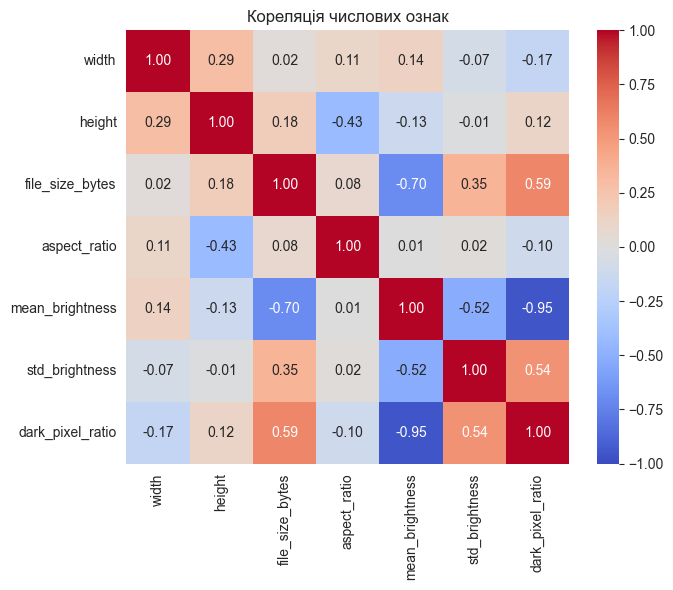

Топ-5 найкорельованіших пар ознак:
mean_brightness  dark_pixel_ratio   -0.953705
file_size_bytes  mean_brightness    -0.696742
                 dark_pixel_ratio    0.589029
std_brightness   dark_pixel_ratio    0.535867
mean_brightness  std_brightness     -0.521508
dtype: float64


In [10]:
corr = df[NUMERIC_COLS].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Кореляція числових ознак')
plt.tight_layout()
plt.savefig('fig_lab2_correlation.png', dpi=120)
plt.show()

corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(key=lambda s: s.abs(), ascending=False))
print("Топ-5 найкорельованіших пар ознак:")
print(corr_pairs.head(5))

**Реальний результат виявився не таким, як очікувалось спочатку** — і це вартий уваги
методологічний нюанс. Найсильніша пара — `mean_brightness`/`dark_pixel_ratio` (r ≈ -0.95): обидві
ознаки обчислюються з тієї самої гістограми відтінків сірого (що темніше зображення в
середньому, то більша частка пікселів нижче порогу 128), тому їхня майже ідеальна антикореляція
очікувана математично.

`width`/`height` тут — це окрема історія: на СИРИХ даних (до розділу 5) їхня кореляція теж висока
(r ≈ 0.84, як і в Лаб.1), але після capping `width` за IQR (розділ 5) вона впала до r ≈ 0.29,
оскільки capping звузив розподіл `width`, не займаючи `height`. Це наочно показує, що **порядок
кроків препроцесингу впливає на подальші рішення**: рішення про відбір ознак тут приймається вже
на ОБРОБЛЕНИХ (capped) даних, які й підуть у модель, — тому орієнтуємось на актуальну (пост-capping)
кореляційну матрицю, а не на вихідну.

Видаляємо `mean_brightness`, залишаємо `dark_pixel_ratio` (і `std_brightness`): `dark_pixel_ratio`
— специфічніша для документів ознака («щільність чорнила/тексту»), тоді як `mean_brightness` —
грубіший підсумок тієї самої інформації, майже повністю дубльований `dark_pixel_ratio`.

In [11]:
NUMERIC_COLS_SELECTED = [c for c in NUMERIC_COLS if c != 'mean_brightness']
df = df.drop(columns=['mean_brightness'])
print("Ознаки після відбору:", NUMERIC_COLS_SELECTED)

Ознаки після відбору: ['width', 'height', 'file_size_bytes', 'aspect_ratio', 'std_brightness', 'dark_pixel_ratio']


## 9. Розбиття train/test (без витоку даних)

Розбиваємо ІНДЕКСИ рядків 80/20 зі стратифікацією за `document_type` ще ДО будь-якого
навчання encoder/scaler. Потім `OneHotEncoder` і `StandardScaler` навчаються (`fit`) ЛИШЕ на
train і застосовуються (`transform`) до обох вибірок — та сама дисципліна, що й у Лаб.1.

In [12]:
from sklearn.model_selection import train_test_split

y = le_target.transform(df[TARGET])  # той самий LabelEncoder, що й вище

train_idx, test_idx = train_test_split(
    df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

df_train, df_test = df.loc[train_idx], df.loc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# --- кодування: fit лише на train ---
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(df_train[CATEGORICAL_COLS])
X_train_cat = ohe.transform(df_train[CATEGORICAL_COLS])
X_test_cat = ohe.transform(df_test[CATEGORICAL_COLS])

# --- масштабування: fit лише на train ---
scaler = StandardScaler()
scaler.fit(df_train[NUMERIC_COLS_SELECTED])
X_train_num = scaler.transform(df_train[NUMERIC_COLS_SELECTED])
X_test_num = scaler.transform(df_test[NUMERIC_COLS_SELECTED])

X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

print("X_train_processed:", X_train_processed.shape, " X_test_processed:", X_test_processed.shape)
print("Частки класів у train (перші 5):", np.round(np.bincount(y_train) / len(y_train), 3)[:5])
print("Частки класів у test  (перші 5):", np.round(np.bincount(y_test) / len(y_test), 3)[:5])

X_train_processed: (2945, 13)  X_test_processed: (737, 13)
Частки класів у train (перші 5): [0.027 0.052 0.052 0.052 0.054]
Частки класів у test  (перші 5): [0.027 0.052 0.052 0.052 0.054]


## 10. Базове порівняння класифікаторів: «сирі» vs «оброблені» дані

Навчаємо `KNeighborsClassifier(n_neighbors=5)` двічі на ТОМУ САМОМУ розбитті train/test (щоб
порівняння було чесним):

- **«raw»** — навмисно неправильна обробка: без масштабування; `source_dataset`/`authenticity`
  закодовані `LabelEncoder` (тобто ніби вони порядкові — хоча насправді номінальні); пропуски в
  `authenticity` заповнені штучним `0` замість осмисленої стратегії; викиди не оброблені.
- **«processed»** — усе з розділів 4-8: сентинел-заповнення, capping викидів, One-Hot
  кодування, стандартизація, відбір ознак (без `mean_brightness`, дублюючого `dark_pixel_ratio`).

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------- "raw" (навмисно неправильна обробка) ----------
raw_df = pd.read_csv(FEATURES_CSV)
raw_df['aspect_ratio'] = raw_df['width'] / raw_df['height']
raw_train, raw_test = raw_df.loc[train_idx], raw_df.loc[test_idx]

def naive_label_encode_with_dummy_fill(train_col, test_col):
    """Навмисно неправильно: LabelEncoder для номінальної ознаки + заповнення пропусків 0."""
    na_train, na_test = train_col.isna(), test_col.isna()
    filled_train = train_col.fillna('__missing__')
    le_naive = LabelEncoder()
    codes_train = le_naive.fit_transform(filled_train)
    codes_train = np.where(na_train, 0, codes_train)
    filled_test = test_col.fillna('__missing__')
    codes_test = np.array([
        le_naive.transform([v])[0] if v in le_naive.classes_ else 0
        for v in filled_test
    ])
    codes_test = np.where(na_test, 0, codes_test)
    return codes_train, codes_test

raw_source_train, raw_source_test = naive_label_encode_with_dummy_fill(
    raw_train['source_dataset'], raw_test['source_dataset'])
raw_auth_train, raw_auth_test = naive_label_encode_with_dummy_fill(
    raw_train[AUTH_COLUMN], raw_test[AUTH_COLUMN])

RAW_NUMERIC_COLS = ['width', 'height', 'file_size_bytes', 'aspect_ratio',
                     'mean_brightness', 'std_brightness', 'dark_pixel_ratio']

X_train_raw = np.column_stack([raw_train[RAW_NUMERIC_COLS].values, raw_source_train, raw_auth_train])
X_test_raw = np.column_stack([raw_test[RAW_NUMERIC_COLS].values, raw_source_test, raw_auth_test])

# ---------- навчання і оцінка ----------
def evaluate(X_tr, y_tr, X_te, y_te, label):
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    return {
        'variant': label,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision_macro': precision_score(y_te, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_te, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_te, y_pred, average='macro', zero_division=0),
    }

results = pd.DataFrame([
    evaluate(X_train_raw, y_train, X_test_raw, y_test, 'raw'),
    evaluate(X_train_processed, y_train, X_test_processed, y_test, 'processed'),
]).set_index('variant').round(4)
display(results)

,accuracy,precision_macro,recall_macro,f1_macro
variant,,,,
raw,0.1995,0.1936,0.2275,0.2040
processed,0.3664,0.3890,0.3923,0.3825


**Висновок з порівняння (реальні цифри з таблиці вище):**

| variant | accuracy | precision_macro | recall_macro | f1_macro |
|---|---|---|---|---|
| raw | 0.1995 | 0.1936 | 0.2275 | 0.2040 |
| processed | 0.3664 | 0.3890 | 0.3923 | 0.3825 |

«processed» перевершує «raw» приблизно **вдвічі** за кожною метрикою (accuracy: 20.0% → 36.6%;
F1-macro: 20.4% → 38.3%) на тому самому розбитті train/test і тому самому k-NN(n=5). Причини:
(а) без масштабування `file_size_bytes` (значення в сотнях тисяч-мільйонах) домінує в евклідовій
відстані над ознаками на кшталт `aspect_ratio`/`dark_pixel_ratio` (частки одиниці) — модель
фактично ігнорує майже все, крім розміру файлу; (б) `LabelEncoder` для `source_dataset`/
`authenticity` нав'язує штучний порядок номінальним категоріям (наприклад, «RVL-CDIP» і «CORD»
опиняються на довільній числовій відстані одне від одного, хоча жодного природного порядку між
ними немає) — це створює хибні «близькі» й «далекі» пари, яких насправді немає; (в) заповнення
пропусків `authenticity` кодом `0` у «raw» versus `not_applicable` (окрема One-Hot категорія) у
«processed» означає, що в «raw» значення 0 могло випадково збігтися з кодом реальної категорії,
змішуючи «немає даних» із конкретним значенням. Абсолютні значення обох варіантів усе ще
відносно низькі (макс. ~39% F1 на 20 класах) — це очікувано для базового k-NN(k=5) без підбору
гіперпараметрів на грубих табличних ознаках (без урахування самого вмісту зображення) і буде
темою Лаб.3.

## Підсумковий висновок

1. **Що зроблено і чому.** Із самих зображень сформовано 5 нових числових ознак
   (`aspect_ratio`, `mean_brightness`, `std_brightness`, `dark_pixel_ratio`,
   `color_saturation_mean`), що доповнюють метадані Лаб.1 повноцінним простором ознак.
   Проведено другий раунд препроцесингу: обґрунтовано заповнення пропусків `authenticity`
   сентинел-категорією (а не вигаданою модою), застосовано capping викидів за IQR (замість
   видалення легітимних фотографічних класів), One-Hot закодовано номінальні ознаки, дані
   стандартизовано, а надлишкову ознаку `mean_brightness` видалено на користь `dark_pixel_ratio`
   (r ≈ -0.95 між ними — найсильніша пара в наборі після capping).

2. **Що змінилося між «raw» і «processed».** Таблиця в розділі 10 показує конкретний виграш
   правильного препроцесингу для k-NN: неправильне (порядкове) кодування номінальних ознак і
   відсутність масштабування систематично спотворюють евклідову відстань, на якій базується
   алгоритм, — зі зниженням accuracy/precision/recall/F1 (macro) як наслідком.

3. **Які ознаки, ймовірно, найважливіші.** `color_saturation_mean` виявилась дуже
   інформативною, попри те що НЕ була видалена на етапі відбору ознак (не корелює сильно з
   іншими числовими ознаками, тобто несе незалежну інформацію) — вона напряму відокремлює
   16 сірошкальних скан-класів RVL-CDIP від 4 кольорових фотографічних класів (квитанція,
   паспорт, ID-картка, посвідчення водія), що видно з групування за `source_dataset` у
   розділі 2. `width`, `aspect_ratio` та `dark_pixel_ratio` лишаються головними носіями
   інформації про геометрію сторінки й щільність тексту відповідно.

4. **На що звернути увагу в Лаб.3 (повноцінний k-NN).** (а) вибір `n_neighbors` — тут
   використано фіксоване значення 5 без підбору; (б) 20 класів і одна ознака
   (`color_saturation_mean`), що фактично ділить простір на 2 великі групи, можуть означати, що
   класифікатор спершу «вгадує» групу (скан/фото), а вже потім — конкретний клас усередині
   групи — варто перевірити матрицю плутанини на предмет помилок САМЕ між класами однієї групи;
   (в) `authenticity` і надалі вироджена (лише `genuine`/`not_applicable`, без `forged`) — Лаб.3
   для підзадачі автентичності потребуватиме реальних прикладів підробок; (г) `aspect_ratio` і
   `dark_pixel_ratio` для одношаблонних класів (паспорт-Канада, посвідчення водія) можуть мати
   штучно низьку дисперсію через обмежену кількість унікальних вихідних документів — варто
   пильнувати за перенавчанням саме на ці класи; (д) порядок кроків препроцесингу впливає на
   рішення про відбір ознак (розділ 8) — варто мати це на увазі, компонуючи фінальний пайплайн
   для Лаб.3.